Testing some REBOUND stuff

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import rebound

In [34]:
# first let's work with what REBOUND does natively, which is to set G=1 and use the default non-symplectic integrator ias15
learning_sim = rebound.Simulation()

# add central parkl (the sun maybe)
learning_sim.add(m=1.0) # masses now measured in units of solar masses

# add jupiter
learning_sim.add(m=1.0*10**(-3), a=1.0, e=0.0) # distances now measured in units of jupiter-sun distances

# add a TINYBOI (massless test particle like an asteroid or sth)
learning_sim.add(a=0.637, e=0.0)

# integrate for 100 time units using the default integrator
learning_sim.integrate(100)

# output the coordinates of the particles at the end of the simulation
for particle in learning_sim.particles:
    print(particle.m, particle.x, particle.y, particle.z)

print(learning_sim.particles)
print('the orbital period of particle 2 is', learning_sim.particles[1].P)
print('the orbital period of particle 3 is', learning_sim.particles[2].P)

print('spacing print')

# output the orbital parameters at the end of the simulation
for o in learning_sim.orbits():
    print(o)

print('the number of timesteps completed in learning_sim is:', learning_sim.steps_done)
# HM okay. well I'm still kind of confused about what exactly what "one time unit" means, but this is starting to make some sense. 

1.0 0.00011334350428005497 0.1004122211963678 0.0
0.001 0.8866564957199772 -0.36223369012184026 0.0
0.0 -0.7108488822925194 0.17485682471058872 0.0
the orbital period of particle 2 is 6.28004606875871
the orbital period of particle 3 is 3.117606632098274
spacing print
<rebound.Orbit instance, a=1.0000000000000002 e=2.233051362411388e-16 inc=0.0 Omega=0.0 omega=5.686920414960851 f=0.11528748359137708>
<rebound.Orbit instance, a=0.6269587838920934 e=0.1463972737756662 inc=0.0 Omega=0.0 omega=0.11541151157654905 f=2.9213383394149837>
the number of timesteps completed in learning_sim is: 1148


(501, 3, 3)
the number of timesteps completed in visualization sim #1 is: 1452
ANYWAY!
[[0.       0.       0.      ]
 [1.       0.       0.      ]
 [0.630999 0.       0.      ]]
[0. 0. 0.]
[1. 0. 0.]
[0.630999 0.       0.      ]


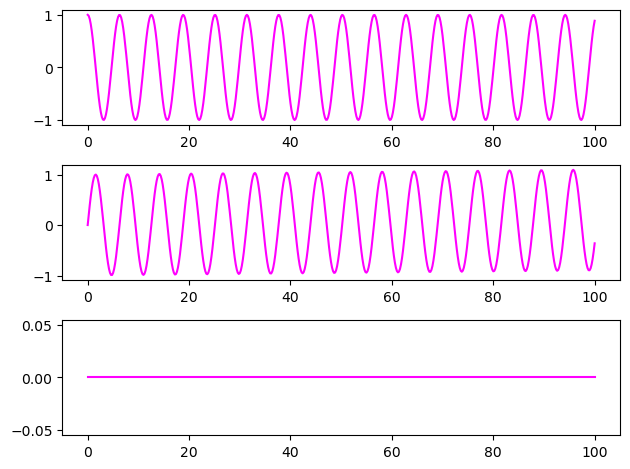

In [77]:
# lets try this again, but now I'd like to collect the data for a fun visualization.
# let's see if I start regretting my lack of experience with SeaBorn....

# initialize the simulation and add the particles
visualization_sim_1 = rebound.Simulation()
visualization_sim_1.add(m=1.0)
visualization_sim_1.add(m=1e-3, a=1.0, e=0.0)
visualization_sim_1.add(m=0.0, a=0.63, e=0.0)

# set the time grid
visualization_sim_1_times = np.linspace(0, 100, 501)
#print(len(visualization_sim_1_times), visualization_sim_1_times[0], visualization_sim_1_times[1]) #does what I want, since the output is 501 0.0 0.2
visualization_sim_1_positions = []

# store the positions
for time in visualization_sim_1_times:
    visualization_sim_1.integrate(time) #integrates the sim. I am sorta controlling the timestep here
    visualization_sim_1_positions.append([[p.x, p.y, p.z] for p in visualization_sim_1.particles])

# convert to a numpy array for ease of data analysis
positions = np.array(visualization_sim_1_positions)
print(positions.shape)
print('the number of timesteps completed in visualization sim #1 is:', visualization_sim_1.steps_done)
print('ANYWAY!')

# Being rather tired at the moment, I am going to put the array interpretation here explicitly
# positions is (time, particle, coord)
print(positions[0]) #particles at time t=0
print(positions[0, 0])
print(positions[0, 1])
print(positions[0, 2]) #x y z of particle 3 at t=0
# et! cetera!
# goodness im tired. 

# make arrays in order to make plots
particle2_trajectory = positions[:, 1, :]
particle2_trajectory_x = particle2_trajectory[:, 0]
particle2_trajectory_y = particle2_trajectory[:, 1]
particle2_trajectory_z = particle2_trajectory[:, 2]

# /now/ make plots
plt.subplot(3, 1, 1)
plt.plot(visualization_sim_1_times, particle2_trajectory_x, color='magenta')
plt.subplot(3, 1, 2)
plt.plot(visualization_sim_1_times, particle2_trajectory_y, color='magenta')
plt.subplot(3, 1, 3)
plt.plot(visualization_sim_1_times, particle2_trajectory_z, color='magenta')
plt.tight_layout()

Text(0.5, 0.92, 'Helix curve showing orbit trajectory')

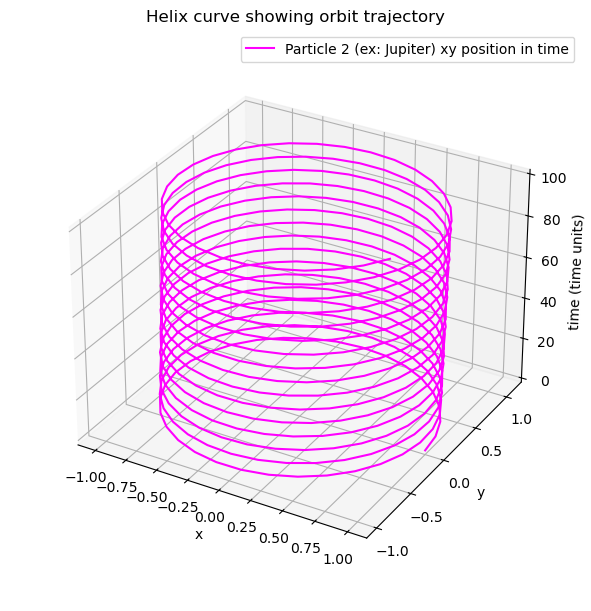

In [78]:
# Since I have the expected lack of z behavior, I can visualize this in 3D by using the z axis as time
# in future plots I may have to use the animation generation FuncAnimation in matplotlib

# PARTICLE 2 (jupiter. why did I do this one first. I dont know)
# define axes 
fig = plt.figure(figsize=(8,6), layout='constrained')
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.9)
ax.plot(particle2_trajectory_x, particle2_trajectory_y, visualization_sim_1_times, 
        label = 'Particle 2 (ex: Jupiter) xy position in time', color='magenta')
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('time (time units)')
ax.set_title('Helix curve showing orbit trajectory')

Text(0.5, 0.92, 'Helix curve showing orbit trajectory')

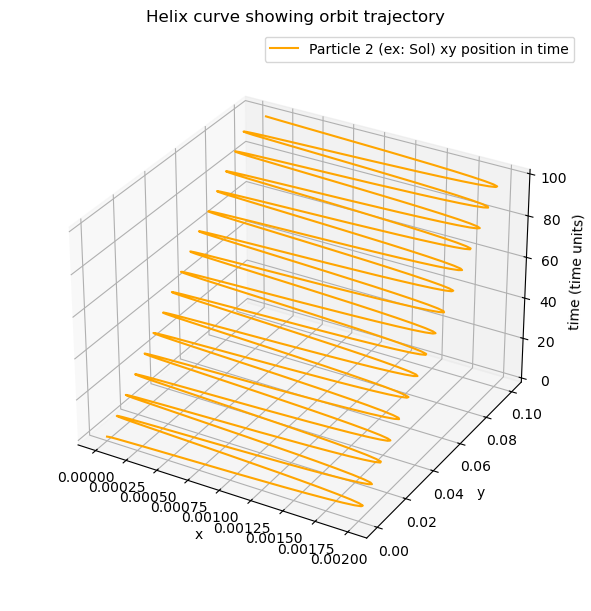

In [75]:
# lets do that for the sun (particle 1)

# make arrays in order to make plots
particle1_trajectory = positions[:, 0, :]
particle1_trajectory_x = particle1_trajectory[:, 0]
particle1_trajectory_y = particle1_trajectory[:, 1]
particle1_trajectory_z = particle1_trajectory[:, 2]

# PARTICLE 1 (Sol)
# define axes 
fig = plt.figure(figsize=(8,6), layout='constrained')
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.9)
ax.plot(particle1_trajectory_x, particle1_trajectory_y, visualization_sim_1_times, 
        label = 'Particle 2 (ex: Sol) xy position in time', color='orange')
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('time (time units)')
ax.set_title('Helix curve showing orbit trajectory')

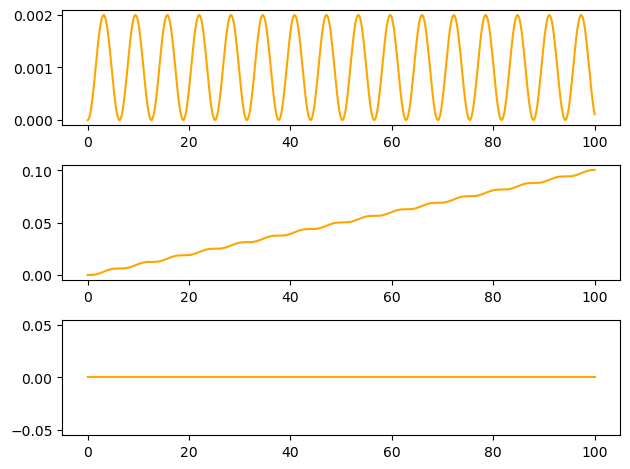

In [76]:
plt.subplot(3, 1, 1)
plt.plot(visualization_sim_1_times, particle1_trajectory_x, color='orange')
plt.subplot(3, 1, 2)
plt.plot(visualization_sim_1_times, particle1_trajectory_y, color='orange')
plt.subplot(3, 1, 3)
plt.plot(visualization_sim_1_times, particle1_trajectory_z, color='orange')
plt.tight_layout()

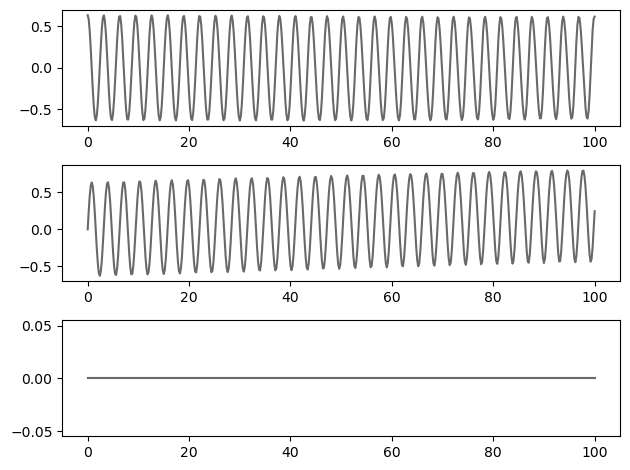

In [80]:
# lets do that, finally, for the test particle (asteroid)

# make arrays in order to make plots
particle3_trajectory = positions[:, 2, :]
particle3_trajectory_x = particle3_trajectory[:, 0]
particle3_trajectory_y = particle3_trajectory[:, 1]
particle3_trajectory_z = particle3_trajectory[:, 2]

# 3plots
plt.subplot(3, 1, 1)
plt.plot(visualization_sim_1_times, particle3_trajectory_x, color='dimgrey')
plt.subplot(3, 1, 2)
plt.plot(visualization_sim_1_times, particle3_trajectory_y, color='dimgrey')
plt.subplot(3, 1, 3)
plt.plot(visualization_sim_1_times, particle3_trajectory_z, color='dimgrey')
plt.tight_layout()

Text(0.5, 0.92, 'Helix curve showing asteroid orbit trajectory')

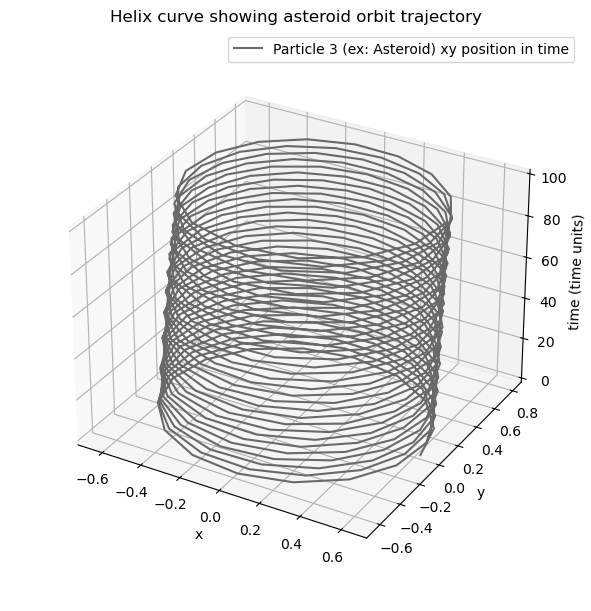

In [81]:
# and now the 3d for the asteroid

# define axes 
fig = plt.figure(figsize=(8,6), layout='constrained')
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.9)
ax.plot(particle3_trajectory_x, particle3_trajectory_y, visualization_sim_1_times, 
        label = 'Particle 3 (ex: Asteroid) xy position in time', color='dimgrey')
ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('time (time units)')
ax.set_title('Helix curve showing asteroid orbit trajectory')

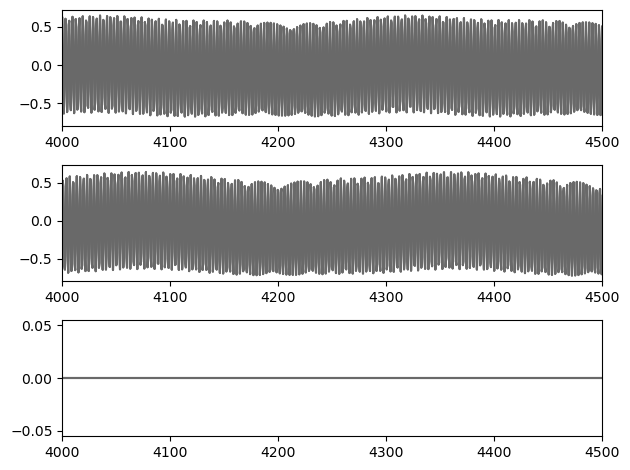

In [93]:
# now lets try doing loooonger sims 
##################################

# Also, the following sims will be done in the CoM frame. This was neglected before, but is important for longer simulations
# this sim has a similar particle setup to the above. 
sim3 = rebound.Simulation()
sim3.add(m=1.0)
sim3.add(m=1.0*10**(-3), a=1.0, e=0.0)
sim3.add(m=0.0, a=0.637, e=0.0)
sim3.move_to_com()

sim3_times = np.linspace(0, 5000, 10000)
sim3_positions = []

for time in sim3_times:
    sim3.integrate(time) #integrates the sim.
    sim3_positions.append([[p.x, p.y, p.z] for p in sim3.particles])

sim3_positions = np.array(sim3_positions)

particle3_trajectory = sim3_positions[:, 2, :]
particle3_trajectory_x = particle3_trajectory[:, 0]
particle3_trajectory_y = particle3_trajectory[:, 1]
particle3_trajectory_z = particle3_trajectory[:, 2]

# 3plots
plt.subplot(3, 1, 1)
plt.plot(sim3_times, particle3_trajectory_x, color='dimgrey')
plt.subplot(3, 1, 2)
plt.plot(sim3_times, particle3_trajectory_y, color='dimgrey')
plt.subplot(3, 1, 3)
plt.plot(sim3_times, particle3_trajectory_z, color='dimgrey')
plt.tight_layout()

# smol chunk of 3plots; overwrite the above
plt.subplot(3, 1, 1)
plt.plot(sim3_times, particle3_trajectory_x, color='dimgrey')
plt.xlim(4000, 4500)
plt.subplot(3, 1, 2)
plt.plot(sim3_times, particle3_trajectory_y, color='dimgrey')
plt.xlim(4000, 4500)
plt.subplot(3, 1, 3)
plt.plot(sim3_times, particle3_trajectory_z, color='dimgrey')
plt.xlim(4000, 4500)
plt.tight_layout()

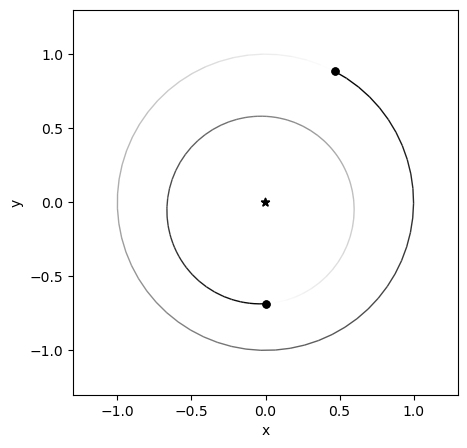

In [92]:
# THIS CELL IS CONNECTED TO THE CELLS ABOVE!
# lets test a thing

fig = rebound.OrbitPlot(sim3)

In [102]:
# now lets try sweeping thru some different semimajor axes for the asteroid
# these sims have a similar particle setup to the above. 

# some variables I need

a_Jupiter = 5.202605226783334 #from NASA Horizons
# Note:
    # resonance depends on the ratio of the orbital periods of the two objects of interest;
    # for ex a 2:1 resonance, the asteroid completes two orbits for every one Jovian year.
    # for small objects, resonance tends to destabilize the orbit

# from Kepler's 3rd law, which states that basically (T1/T2)^2 = (a1/a2)^3. Simple algebra yields:
a_two_to_one = a_Jupiter * (1/2)**(2/3) # it is 3.277435919758706

# test 100 values of the asteroid's semimajor axis from 3.2 AU to 3.3 AU
a_values = np.linspace(3.2, 3.3, 100)

# track the lifetimes of the orbits
lifetimes_two_to_one = []

for a in a_values:
    
    # set up the simulation
    sim4 = rebound.Simulation()
    sim4.integrator = 'whfast'
    sim4.dt = 0.02
    sim4.add(m=1.0)
    sim4.add(m=1.0*10**(-3), a=a_Jupiter, e=0.04836) #this is slightly more realistically Jupiter-ish 
    sim4.add(m=0.0, a=a)
    sim4.move_to_com() #shift to CoM coordinates!

    # Track orbit lifetime
    t_escape = None

    time = 0
    while time < 50000:
        time += sim4.dt
        sim4.integrate(time)
        orbits = sim4.orbits(primary=sim4.particles[0]) #even switching to CoM doesnt really make REBOUND calculate ORBITAL parameters relative to CoM. they're done relative to the primary lol. that was an annoying bug!
        orbit = orbits[1]
        
        if orbit.e > 0.9:
            t_escape = t
            break
    
    lifetimes_two_to_one.append(t_escape)

print(len(lifetimes_two_to_one))

100


NOTE to SELF:
above cell took 1974 seconds to execute, which is about 33 minutes. 

In [103]:
print(lifetimes_two_to_one)

[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


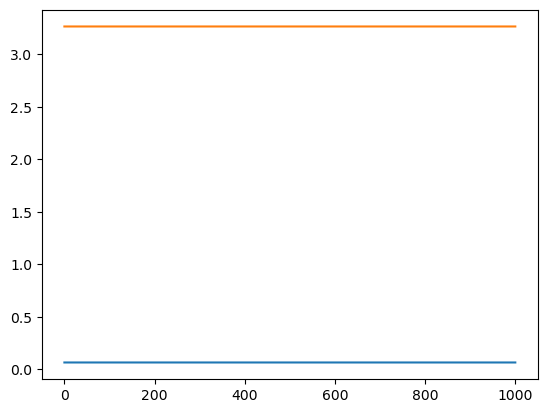

In [107]:
# direct check of asteroid at 2:1

sim5 = rebound.Simulation()
sim5.integrator = 'whfast'
sim5.dt = 0.02
sim5.add(m=1.0)
sim5.add(m=1.0*10**(-3), a=a_Jupiter, e=0.04836) #this is slightly more realistically Jupiter-ish 
sim5.add(m=0.0, a=a_two_to_one)
sim5.move_to_com()

sim5_times = []
sim5_asteroid_eccentricities = []
sim5_asteroid_a = []

t = 0
while t < 1000:
    t += sim5.dt
    sim5.integrate(t)
    orbits = sim4.orbits(primary=sim4.particles[0])
    orbit = orbits[1]
    sim5_times.append(t)
    sim5_asteroid_eccentricities.append(orbit.e)
    sim5_asteroid_a.append(orbit.a)


plt.plot(sim5_times, sim5_asteroid_eccentricities)
plt.plot(sim5_times, sim5_asteroid_a)

Suspicious. 
Ah, the "asteroid" is massless. You probably cannot enforce a Kirkwood gap on asteroids that dont have any mass. 
Let's try this again. 

In [108]:
# test 100 values of the asteroid's semimajor axis from 3.2 AU to 3.3 AU
a_values = np.linspace(3.2, 3.3, 100)

# track the lifetimes of the orbits
lifetimes_two_to_one = []

for a in a_values:
    
    # set up the simulation
    sim4 = rebound.Simulation()
    sim4.integrator = 'whfast'
    sim4.dt = 0.02
    sim4.add(m=1.0)
    sim4.add(m=1e-3, a=a_Jupiter, e=0.04836) #this is slightly more realistically Jupiter-ish 
    sim4.add(m=1e-15, a=a)
    sim4.move_to_com() #shift to CoM coordinates!

    # Track orbit lifetime
    t_escape = None

    time = 0
    while time < 50000:
        time += sim4.dt
        sim4.integrate(time)
        orbits = sim4.orbits(primary=sim4.particles[0]) #even switching to CoM doesnt really make REBOUND calculate ORBITAL parameters relative to CoM. they're done relative to the primary lol. that was an annoying bug!
        orbit = orbits[1]
        
        if orbit.e > 0.9:
            t_escape = t
            break
    
    lifetimes_two_to_one.append(t_escape)

print(len(lifetimes_two_to_one))

100


Hmm, it appears that my earlier hypothesis was incorrect. Even with a massive asteroid, the above cell took 2030 seconds to execute and as the cell below illustrates, none of the starting conditions produced an 'ejection' from the system. 



In [109]:
print(lifetimes_two_to_one)

[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]


50000.01999786406


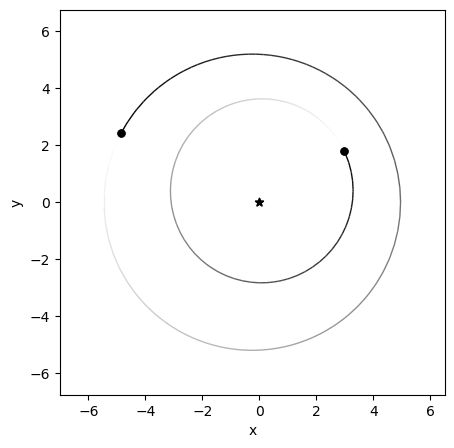

In [115]:
fig = rebound.OrbitPlot(sim5)
print(sim4.t)

Text(0.5, 1.0, 'End positions of test particles after 50000 time units (~8k orbits)')

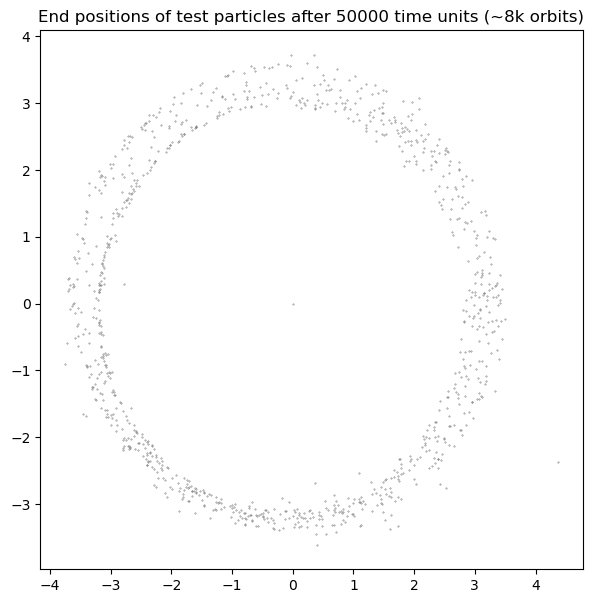

In [132]:
# Wait no. there's a better way to test Kirkwood gap formation. REBOUND has different types of test particles. 
# Type 0 test particles have no mass, and whatever active particles are in the simulation do not feel them
# Type 1 test particles are allowed to have mass and influence the active particles in the simulation
# test particles never influence each other
# In order to ensure that all the test particles behave as test particles,
# the (whateversim).N_active variable must be set to whatever number of real particles YOU put in your simulation.
# Otherwise, the value defaults to -1 and all particles are basically considered active. 

# The better way: run one simulation with a bunch of test particles rather than a bunch of simulations with one test particle each. 
sim_Kirkwood_formation = rebound.Simulation()
sim_Kirkwood_formation.add(m=1.0)
sim_Kirkwood_formation.add(m=1e-3, a=a_Jupiter, e=0.04836)
sim_Kirkwood_formation.move_to_com()
sim_Kirkwood_formation.integrator = 'whfast'
sim_Kirkwood_formation.dt = 0.05

# semimajor axes of interest
a_values = np.linspace(3.0, 3.5, 100)

# Total number of test particles in the simulation
# This is purely here to remind myself of how many particles I want
N_test_particles = 1000

for a in a_values:
    # add 10 particles per semimajor axis. I was tired while I put this here; yes I know this can be done with a loop.
    # f is the true anomaly and sort of tracks where in the orbit the particle is. Ranges from 0 to 2π
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Kirkwood_formation.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)

sim_Kirkwood_formation.N_active = 2

# Put here the code for storing positions or orbital parameters later. I might want to do that

# integrate the sim
sim_Kirkwood_formation.integrate(50000)

test_particle_x_positions_Kirkwood_formation = []
test_particle_y_positions_Kirkwood_formation = []
for p in sim_Kirkwood_formation.particles:
    test_particle_x_positions_Kirkwood_formation.append(p.x)
    test_particle_y_positions_Kirkwood_formation.append(p.y)


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot()
ax.scatter(test_particle_x_positions_Kirkwood_formation, 
            test_particle_y_positions_Kirkwood_formation,
           s=0.1, color='dimgrey')
ax.set_title('End positions of test particles after 50000 time units (~8k orbits)')


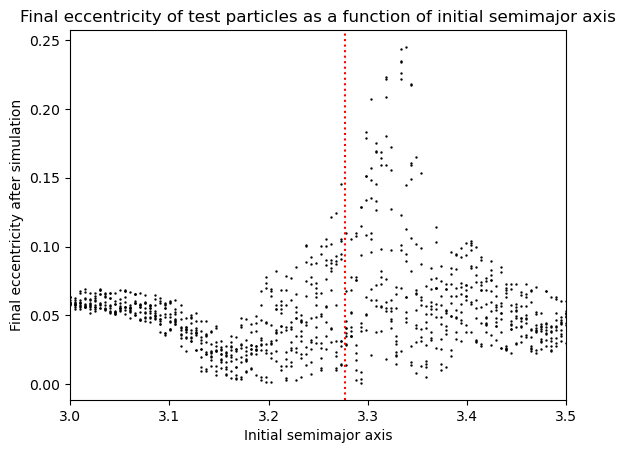

In [153]:
# how about the final eccentricities as a function of initial semimajor axes?

final_eccentricities = []
for orbit in sim_Kirkwood_formation.orbits():
    final_eccentricities.append(orbit.e)

initial_semimaj = [1]
for a in a_values:
    for i in range(10):
       initial_semimaj.append(a)

plt.scatter(initial_semimaj, final_eccentricities, s=0.5, color='k')
plt.title('Final eccentricity of test particles as a function of initial semimajor axis')
plt.xlim(3.0, 3.5)
plt.xlabel('Initial semimajor axis')
plt.ylabel('Final eccentricity after simulation')
plt.axvline(x=3.277, color='r', ls='dotted')

particles within +- 0.03AU of resonance before sim: 120
particles within +- 0.03AU of resonance after sim: 100
particles with semimajor axis between 3.29AU and 3.367AU before sim: 150
particles with semimajor axis between 3.29AU and 3.367AU after sim: 99
particles with semimajor axis between 3.1AU and 3.2AU before sim: 200
particles with semimajor axis between 3.1AU and 3.2AU after sim: 206


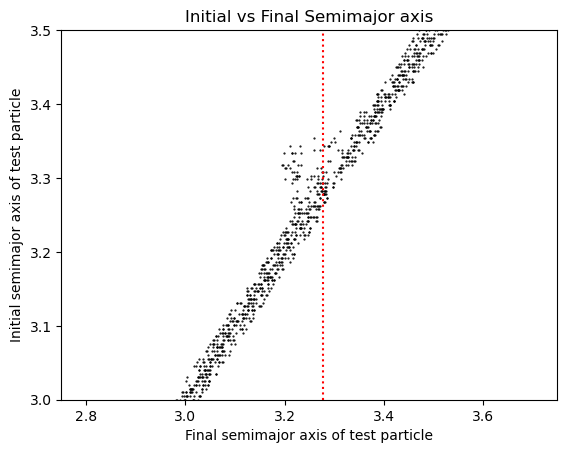

In [178]:
# What about the final semimajor axis as a function of initial semimajor axis?

final_semimaj = []
for orbit in sim_Kirkwood_formation.orbits():
    final_semimaj.append(orbit.a)

plt.scatter(final_semimaj, initial_semimaj, color='k', s=0.3)
plt.ylim(3.0, 3.5)
plt.xlim(2.75, 3.75)
plt.ylabel('Initial semimajor axis of test particle')
plt.xlabel('Final semimajor axis of test particle')
plt.title('Initial vs Final Semimajor axis')
plt.axvline(x=3.277, color='r', ls='dotted')

# how many test particles are there with semimajor axis between 3.277435919758706 +- 0.03 before vs after the sim?
low = 3.277435919758706 - 0.03
high = 3.277435919758706 + 0.03
N_in_tol_before = sum(1 for a in initial_semimaj if low <= a <= high)
print('particles within +- 0.03AU of resonance before sim:', N_in_tol_before)
N_in_tol_after = sum(1 for a in final_semimaj if low <= a <= high)
print('particles within +- 0.03AU of resonance after sim:', N_in_tol_after)

# compare number of particles in this range before and after sim
low = 3.29
high = 3.367
N_in_tol_before = sum(1 for a in initial_semimaj if low <= a <= high)
print('particles with semimajor axis between 3.29AU and 3.367AU before sim:', N_in_tol_before)
N_in_tol_after = sum(1 for a in final_semimaj if low <= a <= high)
print('particles with semimajor axis between 3.29AU and 3.367AU after sim:', N_in_tol_after)

#compare random range for control
low = 3.1
high = 3.2
N_in_tol_before = sum(1 for a in initial_semimaj if low <= a <= high)
print('particles with semimajor axis between 3.1AU and 3.2AU before sim:', N_in_tol_before)
N_in_tol_after = sum(1 for a in final_semimaj if low <= a <= high)
print('particles with semimajor axis between 3.1AU and 3.2AU after sim:', N_in_tol_after)

I'd like to compare the overall "density" of those two arrays, honestly. Unsure how to do that at the moment, though. 
I'd also REALLY like to widen the range of semimajor axes tested, because the literature states that the 2:1 asteroid:Jupiter is the hardest to see.  

Text(0.5, 1.0, 'Broad Kirkwood Gap. End positions of test particles after 500000 time units (~80k orbits)')

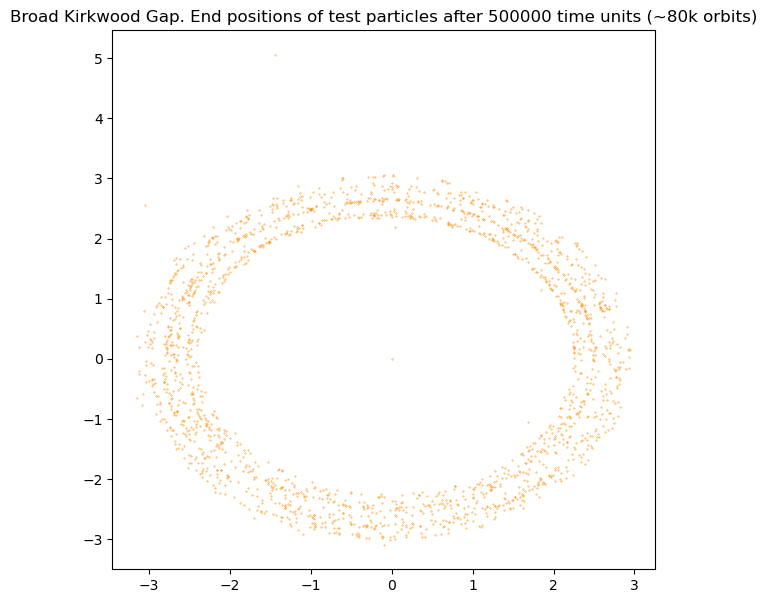

In [188]:
# let's scan over a wider range of semimajor axes for the asteroids!

# set up the simulation
sim_Broad_Kirkwood = rebound.Simulation()
sim_Broad_Kirkwood.add(m=1.0)
sim_Broad_Kirkwood.add(m=1e-3, a=a_Jupiter, e=0.04836)
sim_Broad_Kirkwood.move_to_com()
sim_Broad_Kirkwood.integrator = 'whfast'
sim_Broad_Kirkwood.dt = 0.1

# semimajor axes of interest
a_values_Broad_Kirkwood = np.linspace(2.3, 3.0, 200)

for a in a_values_Broad_Kirkwood:
    # add 10 particles per semimajor axis. I was tired while I put this here; yes I know this can be done with a loop.
    # f is the true anomaly and sort of tracks where in the orbit the particle is. Ranges from 0 to 2π
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)
    sim_Broad_Kirkwood.add(m=0.0, a=a, f=np.random.rand()*2.0*np.pi)

# ensure the semi active particles are in fact semi active and NOT active
sim_Broad_Kirkwood.N_active = 2

# integrate the sim
sim_Broad_Kirkwood.integrate(500000)

test_particle_x_positions_Broad_Kirkwood = []
test_particle_y_positions_Broad_Kirkwood = []
for p in sim_Broad_Kirkwood.particles:
    test_particle_x_positions_Broad_Kirkwood.append(p.x)
    test_particle_y_positions_Broad_Kirkwood.append(p.y)


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot()
ax.scatter(test_particle_x_positions_Broad_Kirkwood, 
            test_particle_y_positions_Broad_Kirkwood,
           s=0.1, color='darkorange')
ax.set_title('Broad Kirkwood Gap. End positions of test particles after 500000 time units (~80k orbits)')

Text(0.5, 1.0, 'Broad Kirkwood Gap. End positions of test particles after 500000 time units (~80k orbits)')

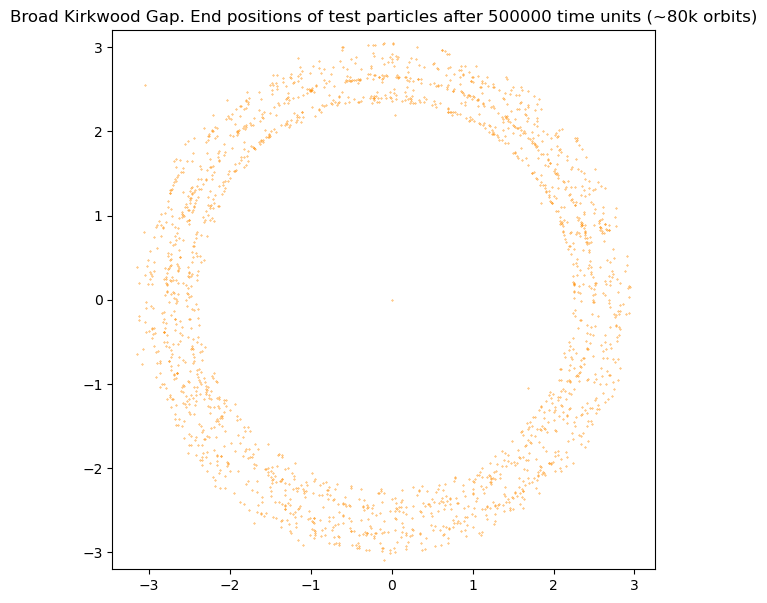

In [190]:
# lets try that again and make the plot less awful!

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot()
ax.scatter(test_particle_x_positions_Broad_Kirkwood, 
            test_particle_y_positions_Broad_Kirkwood,
           s=0.1, color='darkorange')
ax.set_ylim(-3.2, 3.2)
ax.set_title('Broad Kirkwood Gap. End positions of test particles after 500000 time units (~80k orbits)')

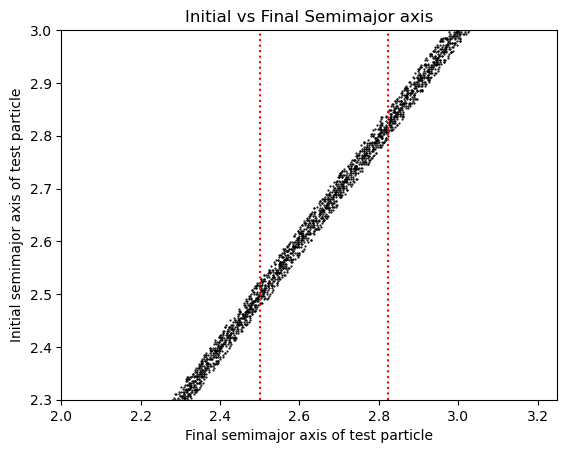

In [197]:
final_semimaj_Broad_Kirkwood = []
for o in sim_Broad_Kirkwood.orbits():
    final_semimaj_Broad_Kirkwood.append(o.a)

initial_semimaj_Broad_Kirkwood = [1]
for a in a_values_Broad_Kirkwood:
    for i in range(10):
       initial_semimaj_Broad_Kirkwood.append(a)

plt.scatter(final_semimaj_Broad_Kirkwood, initial_semimaj_Broad_Kirkwood, color='k', s=0.3)
plt.ylim(2.3, 3.0)
plt.xlim(2.0, 3.25)
plt.ylabel('Initial semimajor axis of test particle')
plt.xlabel('Final semimajor axis of test particle')
plt.title('Initial vs Final Semimajor axis')
plt.axvline(x=2.501, color='r', ls='dotted')
plt.axvline(x=2.824, color='r', ls='dotted')